# HKT Single-Country Production: Large-Bubble State Paths

This notebook uses the large-bubble calibration from `13_single_country_production_tail_approximation_analysis.ipynb` and plots $\phi_t$, $q_t$, $e_t$, and $G_t$ over $t=0,\ldots,60$ for two state-contingent outcomes:

- **$u$ continues:** the unbalanced-growth block evaluated along the all-$u$ knowledge path.
- **switch to $b$:** the balanced-growth block evaluated at the same predetermined all-$u$ knowledge stock $n_t$.

Using the same $n_t$ in both blocks isolates the state-contingent jump at each date. The persistence probability is retained from the large-bubble calibration, although it does not enter these static real-side blocks.

In [1]:
using Pkg

function find_project_dir(start_dir=pwd())
    direct = joinpath(start_dir, "Codes")
    isfile(joinpath(direct, "Project.toml")) && return direct
    dir = start_dir
    while true
        isfile(joinpath(dir, "Project.toml")) && return dir
        parent = dirname(dir)
        parent == dir && error("Could not locate Codes/Project.toml from $(start_dir)")
        dir = parent
    end
end

const PROJECT_DIR = find_project_dir()
Pkg.activate(PROJECT_DIR)
include(joinpath(PROJECT_DIR, "Single_country_production", "SingleCountryProductionOLG.jl"))

using Plots, LaTeXStrings, Printf
using Plots.PlotMeasures

gr()
default(size=(1040, 760), framestyle=:box, grid=:y, legend=:best,
        fontfamily="Computer Modern", linewidth=2,
        titlefontsize=11, guidefontsize=10, tickfontsize=9, legendfontsize=8,
        left_margin=8mm, right_margin=6mm, top_margin=7mm, bottom_margin=8mm)

const OUTDIR = joinpath(PROJECT_DIR, "Single_country_production",
                        "outputs_hkt_single_country_large_bubble_state_paths")
isdir(OUTDIR) || mkpath(OUTDIR)

println("Project directory: ", PROJECT_DIR)
println("Output directory:  ", OUTDIR)

  Activating 

Project directory: /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes

project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes`



Output directory:  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Single_country_production/outputs_hkt_single_country_large_bubble_state_paths


## 1. Large-bubble calibration

The primitives match notebook 13 exactly, except that the requested plotted horizon is set to 60.

In [2]:
const HORIZON = 60
p = HKTParams(T=HORIZON, γ=0.25, ξu=2.0, λu=1.5, ξb=0.5, λb=0.5)
pi_persist = 0.80

println("Large-bubble calibration:")
@printf("  T=%d, beta=%.3f, gamma=%.3f, alpha=%.3f, rho=%.3f, theta=%.3f, aH=%.3f\n",
        HORIZON, p.β, p.γ, p.α, p.ρ, p.θ, p.aH)
@printf("  xi_u=%.3f, lambda_u=%.3f, xi_b=%.3f, lambda_b=%.3f, pi=%.3f\n",
        p.ξu, p.λu, p.ξb, p.λb, pi_persist)

Large-bubble calibration:


  T=60, beta=0.500, gamma=0.250, alpha=0.500, rho=2.000, theta=0.500, aH=0.200
  xi_u=2.000, lambda_u=1.500, xi_b=0.500, lambda_b=0.500, pi=0.800


## 2. State-contingent paths

Knowledge follows the all-$u$ law, $n_{t+1}=G_t^u n_t$. At each resulting $n_t$, the notebook evaluates both `hkt_block(..., :u)` and the switch-state counterfactual `hkt_block(..., :b)`. The per-variety stock price is $q_t^z=(q_t^z/d_t^z)(D_t^z/n_t)$.

In [3]:
stock_price_from_block(block, n) = block.PD_pv * (block.D / n)

function build_state_paths(p::HKTParams; horizon::Int=60)
    @assert horizon >= 1
    t = collect(0:horizon)
    n = Vector{Float64}(undef, horizon + 1)
    n[1] = p.n0

    phi_u = zeros(horizon + 1); phi_b = zeros(horizon + 1)
    q_u = zeros(horizon + 1); q_b = zeros(horizon + 1)
    e_u = zeros(horizon + 1); e_b = zeros(horizon + 1)
    G_u = zeros(horizon + 1); G_b = zeros(horizon + 1)

    for i in eachindex(t)
        u = hkt_block(p, n[i], :u)
        b = hkt_block(p, n[i], :b)

        phi_u[i], phi_b[i] = u.φ, b.φ
        q_u[i], q_b[i] = stock_price_from_block(u, n[i]), stock_price_from_block(b, n[i])
        e_u[i], e_b[i] = u.e, b.e
        G_u[i], G_b[i] = u.G, b.G

        i <= horizon && (n[i + 1] = G_u[i] * n[i])
    end

    return (; t, n, phi_u, phi_b, q_u, q_b, e_u, e_b, G_u, G_b)
end

paths = build_state_paths(p; horizon=HORIZON)
@assert length(paths.t) == HORIZON + 1
@assert paths.t[1] == 0 && paths.t[end] == HORIZON
@assert all(isfinite, vcat(paths.phi_u, paths.phi_b, paths.q_u, paths.q_b,
                            paths.e_u, paths.e_b, paths.G_u, paths.G_b))
@assert all(>(0), vcat(paths.q_u, paths.q_b, paths.e_u, paths.e_b, paths.G_u, paths.G_b))

println("Path checkpoints:")
@printf("%-4s %10s %10s %12s %12s %12s %12s %10s %10s\n",
        "t", "phi_u", "phi_b", "q_u", "q_b", "e_u", "e_b", "G_u", "G_b")
for date in (0, 10, 20, 40, 60)
    i = date + 1
    @printf("%-4d %10.6f %10.6f %12.4e %12.4e %12.4e %12.4e %10.6f %10.6f\n",
            date, paths.phi_u[i], paths.phi_b[i], paths.q_u[i], paths.q_b[i],
            paths.e_u[i], paths.e_b[i], paths.G_u[i], paths.G_b[i])
end

Path checkpoints:


t         phi_u      phi_b          q_u          q_b          e_u          e_b        G_u        G_b
0      0.693303   0.693303   7.9450e-01   7.9450e-01   1.6865e+00   1.6865e+00   1.061339   1.061339


10     0.591198   0.693303   1.1395e+00   5.6569e-01   4.8631e+00   2.3686e+00   1.081760   1.061339
20     0.480133   0.693303   1.8068e+00   3.6486e-01   1.8916e+01   3.6724e+00   1.103973   1.061339
40     0.272635   0.693303   6.0764e+00   1.1297e-01   6.8850e+02   1.1860e+01   1.145473   1.061339
60     0.131474   0.693303   2.7560e+01   2.5581e-02   6.2406e+04   5.2379e+01   1.173705   1.061339


In [4]:
function write_state_paths_csv(paths; filename=joinpath(OUTDIR, "hkt_large_bubble_state_paths.csv"))
    open(filename, "w") do io
        println(io, "t,n,phi_u,phi_b,q_u,q_b,e_u,e_b,G_u,G_b")
        for i in eachindex(paths.t)
            @printf(io, "%d,%.16g,%.16g,%.16g,%.16g,%.16g,%.16g,%.16g,%.16g,%.16g\n",
                    paths.t[i], paths.n[i], paths.phi_u[i], paths.phi_b[i],
                    paths.q_u[i], paths.q_b[i], paths.e_u[i], paths.e_b[i],
                    paths.G_u[i], paths.G_b[i])
        end
    end
    return filename
end

csv_path = write_state_paths_csv(paths)
println("Wrote ", csv_path)

Wrote /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Single_country_production/outputs_hkt_single_country_large_bubble_state_paths/hkt_large_bubble_state_paths.csv

## 3. Comparison plots

Wrote /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Single_country_production/outputs_hkt_single_country_large_bubble_state_paths/hkt_large_bubble_u_continue_vs_switch_b_paths.png

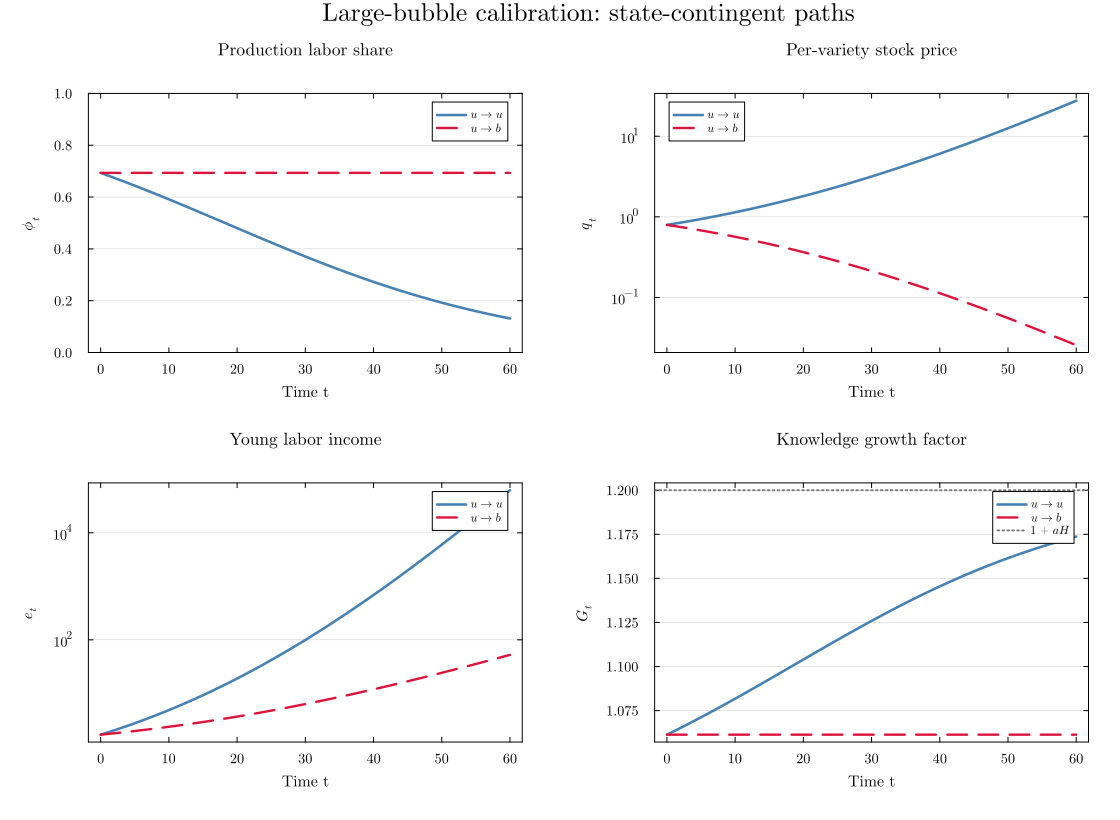

In [5]:
function plot_state_paths(paths; filename=joinpath(OUTDIR, "hkt_large_bubble_u_continue_vs_switch_b_paths.png"))
    continue_style = (; color=:steelblue, lw=2.6, label=L"u\rightarrow u")
    switch_style = (; color=:crimson, lw=2.4, ls=:dash, label=L"u\rightarrow b")

    p_phi = plot(paths.t, paths.phi_u; xlabel="Time t", ylabel=L"\phi_t",
                 title="Production labor share", ylim=(0, 1), continue_style...)
    plot!(p_phi, paths.t, paths.phi_b; switch_style...)

    p_q = plot(paths.t, paths.q_u; xlabel="Time t", ylabel=L"q_t",
               title="Per-variety stock price", yscale=:log10, continue_style...)
    plot!(p_q, paths.t, paths.q_b; switch_style...)

    p_e = plot(paths.t, paths.e_u; xlabel="Time t", ylabel=L"e_t",
               title="Young labor income", yscale=:log10, continue_style...)
    plot!(p_e, paths.t, paths.e_b; switch_style...)

    p_G = plot(paths.t, paths.G_u; xlabel="Time t", ylabel=L"G_t",
               title="Knowledge growth factor", continue_style...)
    plot!(p_G, paths.t, paths.G_b; switch_style...)
    hline!(p_G, [1 + p.aH], color=:gray45, ls=:dot, lw=1.8, label=L"1+aH")

    fig = plot(p_phi, p_q, p_e, p_G, layout=(2, 2), size=(1120, 820),
               bottom_margin=8mm, plot_title="Large-bubble calibration: state-contingent paths")
    savefig(fig, filename)
    return fig, filename
end

state_paths_fig, figure_path = plot_state_paths(paths)
println("Wrote ", figure_path)
state_paths_fig

## 4. Reading the figure

The $u\to u$ curves determine the evolving knowledge stock. The $u\to b$ curves are date-by-date switch outcomes at that same predetermined stock, not a second recursively simulated knowledge history. This convention matches the single-country model's `run_hkt` comparison and makes each vertical gap the immediate state-contingent change.